<a href="https://colab.research.google.com/github/alexyh1/STA4000/blob/main/code/chapter2_kantorovich/2.1_Exact_OT_Discrete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 48.4 MB/s eta 0:00:00


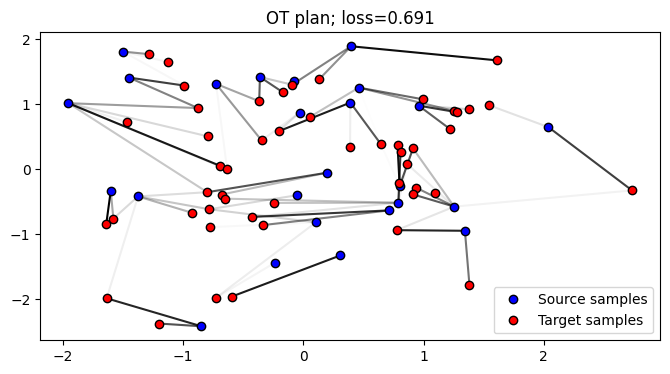

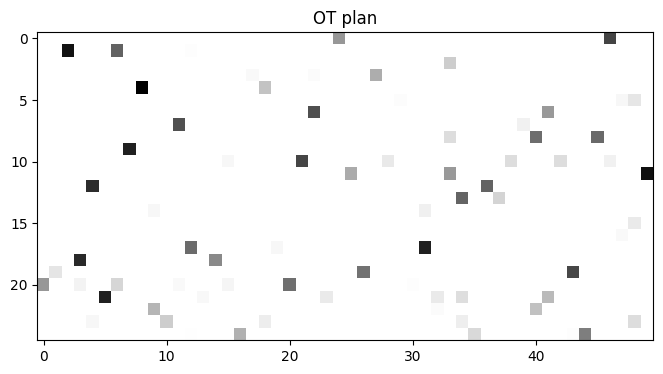

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import ot
from ot.plot import plot2D_samples_mat
import time


np.random.seed(4000)

n1 = 25
n2 = 50
a = np.random.rand(25)
a = a / sum(a)
b = np.random.rand(50)
b = b / sum(b)

x1 = np.random.randn(n1, 2)
x2 = np.random.randn(n2, 2)

sol = ot.solve_sample(x1, x2, a, b)

# get the OT plan
P = sol.plan

# get the OT loss
loss = sol.value


style = {"markeredgecolor": "k"}
def plot_plan(P=None, title="", axis=True):
    if P is not None:
        plot2D_samples_mat(x1, x2, P)
    plt.plot(x1[:, 0], x1[:, 1], "ob", label="Source samples", **style)
    plt.plot(x2[:, 0], x2[:, 1], "or", label="Target samples", **style)
    if not axis:
        plt.axis("off")
    plt.title(title)


plt.figure(1, (8, 4))
plot_plan(P, "OT plan; loss={:.3f}".format(loss))
plt.legend(loc=0)
plt.show()

plt.figure(2, (8, 4))
plt.imshow(P, cmap="Greys")
plt.title("OT plan")
plt.show()